In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [33]:
df = pd.read_csv(r"E:\DS_AI_Internship\src\Day28\insurance_data.csv")
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


In [34]:
df.shape

(27, 2)

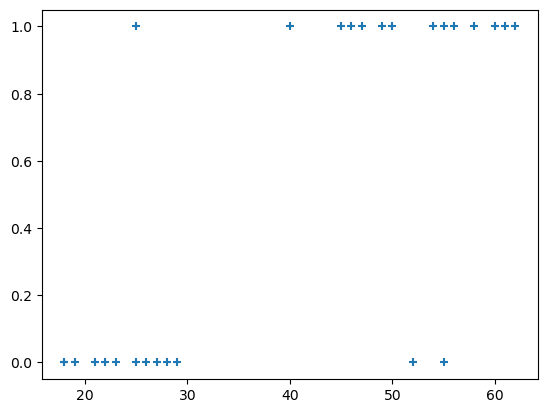

In [35]:
plt.scatter(df.age,df.bought_insurance,marker='+')

In [36]:
x=df[['age']]
y=df[['bought_insurance']]

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.8,random_state=42)

In [39]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train.values.ravel())

LogisticRegression()

In [42]:
model.coef_

array([[0.11523991]])

In [43]:
model.intercept_

array([-5.64857389])

In [45]:
y_predicted=model.predict(x_test)
y_predicted

array([1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0],
      dtype=int64)

In [47]:
df['probs']=model.predict_proba(df[['age']])[:,1]
df

,age,bought_insurance,probs
0,22,0,0.042562
1,25,0,0.059102
2,47,1,0.442185
3,52,0,0.585138
4,46,1,0.413980
5,56,1,0.691013
6,55,0,0.665883
7,60,1,0.780026
8,62,1,0.817022
9,61,1,0.799161


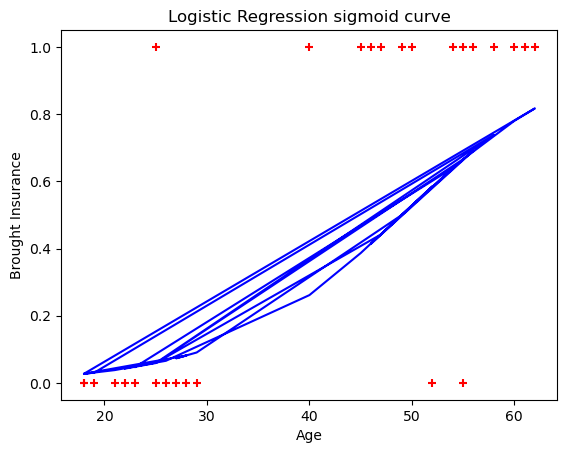

In [48]:
plt.scatter(df.age,df.bought_insurance,marker='+',color='red')
plt.plot(df['age'],df['probs'],color='blue')
plt.xlabel("Age")
plt.ylabel("Brought Insurance")
plt.title("Logistic Regression sigmoid curve")
plt.show()

In [66]:
import math
def sigmoid(x):
    return 1/(1+math.exp(-x))

In [67]:
def prediction_function(age):
    z=0.112*age+(-4.20)
    y=sigmoid(z)
    return y

In [68]:
age = 35
prediction_function(age)

0.43045377606077095

In [70]:
age=40
prediction_function(age)

0.569546223939229

In [71]:
age=37.5
prediction_function(age)

0.5

In [72]:
age=82
prediction_function(age)

0.9931999362344026

In [74]:
# 82,66, 58, 77, 13, 1
from sklearn.metrics import accuracy_score
y_pred=model.predict(x)
accuracy=accuracy_score(y,y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7037037037037037
